# Projektion von Koordinaten klinischer Studienzentren für die Kartierung mit PROC GPROJECT

## Zusammenfassung

Ein Clinical-Operations-Team muss den geografischen Fußabdruck einer Multi-Center-Phase-III-Studie auf einer flachen Karte darstellen. Dieses Notebook erzeugt synthetische Längen-/Breitengrad-Koordinaten für Studienzentren, die um fünf US-Regions-Hubs geclustert sind, und nutzt dann **PROC GPROJECT**, um die sphärischen Koordinaten mit drei Projektionsmethoden (Albers flächentreu, Lambert winkeltreu mit benutzerdefinierten Standardparallelen und regionalem Clipping sowie Gnomonisch, zentriert auf das kontinentale U.S.-Gebiet) in kartesische X/Y-Werte umzuwandeln, und veranschaulicht so, wie Projektionswahl und Clipping eine Zentrenkarte beeinflussen.

## Datenquellen

| Datensatz | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 Hubs x 12 Zentren) | `site_id` ($8-ID), `region` ($20), `x` (Längengrad, Grad, Ost-positiv), `y` (Breitengrad, Grad), `enroll` (eingeschriebene Teilnehmer), `segment` (Kartensegment-ID) | Synthetische Phase-III-Studienzentren-Standorte, verteilt um fünf US-Regions-Hubs (Westen, Mittlerer Westen, Nordosten, Süden, Südosten) mittels `rand('normal')`-Streuung und `rand('poisson')`-Rekrutierungszahlen |

# Projektion von Koordinaten klinischer Studienzentren mit PROC GPROJECT

Wenn ein Sponsor eine geografisch verstreute Phase-III-Studie durchführt, möchte die Clinical-Operations-Gruppe oft eine einzige Karte, die jedes Prüfzentrum zeigt, skaliert oder eingefärbt nach Rekrutierung. Standortangaben liegen als **Längen-/Breitengrad-Paare** vor, aber eine flache Karte benötigt **planare X/Y-Koordinaten**. `PROC GPROJECT` führt diese Umwandlung von sphärisch zu kartesisch durch und wendet dabei eine kartografische Projektion an, sodass Entfernungen und Flächen sinnvoll dargestellt werden.

In diesem Notebook werden wir:

1. Synthetische Zentrenkoordinaten erzeugen, geclustert um fünf US-Regions-Hubs.
2. Die standardmäßige **Albers-flächentreue** Projektion anwenden.
3. Eine **Lambert-winkeltreue** Projektion mit benutzerdefinierten Standardparallelen anwenden und auf das zusammenhängende U.S.-Gebiet zuschneiden.
4. Eine **gnomonische** Projektion anwenden, zentriert auf die geografische Mitte des Landes, wobei die Originalkoordinaten mit `ASIS` erhalten bleiben.

Alles ist in sich geschlossen: keine externen Dateien, kein Netzwerk.

## Schritt 1 — Synthetische Zentrenkoordinaten erzeugen

Wir setzen den Startwert des Zufallszahlengenerators mit `call streaminit` für Reproduzierbarkeit und platzieren dann 12 Zentren um jede von fünf regionalen Hub-Städten. Längengrade werden Ost-positiv in Grad gespeichert (negativ für die westliche Hemisphäre), Breitengrade in Grad. Jede Zeile trägt außerdem eine Rekrutierungszahl und eine Variable `segment` (GPROJECT erhält Nicht-Koordinatenspalten während der Projektion).

In [1]:
DATEN trial_sites;
    AUFRUFEN streaminit(20260531);
    LÄNGE site_id $8 region $20;
    /* Fuenf US-Regions-Hub-Zentren: Laengengrad (Ost+), Breitengrad */
    FELD clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    FELD clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    AUSFÜHRUNG hub = 1 BIS 5;
        WENN hub = 1 DANN region = 'Westen';
        SONST WENN hub = 2 DANN region = 'Mittlerer Westen';
        SONST WENN hub = 3 DANN region = 'Nordosten';
        SONST WENN hub = 4 DANN region = 'Süden';
        SONST region = 'Südosten';
        AUSFÜHRUNG s = 1 BIS 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* Laengengrad, Grad */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* Breitengrad, Grad */
            enroll  = round(rand('poisson', 60));           /* eingeschriebene Teilnehmer */
            segment = 1;
            AUSGABE;
        ENDE;
    ENDE;
    ENTFERNEN hub s;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=trial_sites(obs=10) BEZEICHNUNG;
    BEZEICHNUNG site_id="Zentrums-ID" region="Region" x="Längengrad" y="Breitengrad"
          enroll="Eingeschriebene" segment="Segment";
    TITEL "Stichprobe synthetischer klinischer Studienzentren (unprojiziert lon/lat)";
AUSFÜHREN;

                       Stichprobe synthetischer klinischer Studienzentren (unprojiziert lon/lat)                        

  Obs  Zentrums-ID  Region       Längengrad    Breitengrad  Eingeschriebene  Segment
    1  S101         Westen  -121.6437232216  37.7677668495               65        1
    2  S102         Westen  -120.7384024716  37.5083287903               61        1
    3  S103         Westen  -121.5133780284  37.8633933883               72        1
    4  S104         Westen  -121.2086817368  38.7723343392               68        1
    5  S105         Westen  -121.0499572297   37.175813806               54        1
    6  S106         Westen  -124.0531899967   35.778231667               72        1
    7  S107         Westen  -120.9370181032  39.0576714397               64        1
    8  S108         Westen  -126.8495029747  36.6474680375               55        1
    9  S109         Westen   -123.475989897  37.1427965254               56        1
   10  S110         Westen  


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Schritt 2 — Standardmäßige Albers-flächentreue Projektion

Die **Albers**-flächentreue Kegelprojektion ist der GPROJECT-Standard und eine sinnvolle Wahl für eine Karte im Landesmaßstab, bei der die *relative Fläche* erhalten bleiben soll (z. B. beim Vergleich der Größe regionaler Einzugsgebiete).

Da unsere Koordinaten in **Grad** mit **Ost-positivem Längengrad** gespeichert sind, geben wir die Optionen `DEGREE` und `EASTLONG` an. Die `ID`-Anweisung benennt die Variable, die jede Einheit eindeutig identifiziert; die projizierten planaren Koordinaten werden in `x` und `y` im `OUT=`-Datensatz zurückgeschrieben.

In [2]:
PROZEDUR GPROJECT DATEN=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=sites_albers(obs=10) BEZEICHNUNG;
    BEZEICHNUNG site_id="Zentrums-ID" region="Region" x="X (projiziert)" y="Y (projiziert)"
          enroll="Eingeschriebene" segment="Segment";
    TITEL "Studienzentren nach Albers-flächentreuer Projektion (planare X/Y)";
AUSFÜHREN;

                       Stichprobe synthetischer klinischer Studienzentren (unprojiziert lon/lat)                        

                           Studienzentren nach Albers-flächentreuer Projektion (planare X/Y)                            

  Obs  Zentrums-ID  Region  X (projiziert)  Y (projiziert)  Eingeschriebene  Segment
    1  S101         Westen    -0.346124731    0.0516986079               65        1
    2  S102         Westen   -0.3353644139    0.0440400181               61        1
    3  S103         Westen   -0.3439609675    0.0528501365               72        1
    4  S104         Westen   -0.3357513354     0.067213083               68        1
    5  S105         Westen   -0.3410170723    0.0394882801               54        1
    6  S106         Westen   -0.3879364507    0.0273340733               72        1
    7  S107         Westen   -0.3309127579    0.0711146305               64        1
    8  S108         Westen   -0.4204191205    0.0538118922               55 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Schritt 3 — Lambert-winkeltreue Projektion mit benutzerdefinierten Parallelen und Clipping

Die **Lambert-winkeltreue** Kegelprojektion erhält *Form und lokale Winkel*, was vorzuziehen ist, wenn die Karte für Navigation oder das Überlagern richtungsabhängiger Merkmale genutzt wird. Für das zusammenhängende U.S.-Gebiet sind Standardparallelen nahe 33 Grad N und 45 Grad N üblich, daher setzen wir sie explizit mit `PARALLEL1=` und `PARALLEL2=`.

Wir schränken die Karte außerdem mit den Clipping-Optionen `LATMIN=`, `LATMAX=`, `LONGMIN=` und `LONGMAX=` auf das zusammenhängende U.S.-Fenster ein. Zentren außerhalb dieser Längen-/Breitengrad-Box werden vor der Projektion verworfen, sodass die Anzahl der Ausgabebeobachtungen niedriger sein kann als die der Eingabe.

In [3]:
PROZEDUR GPROJECT DATEN=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=sites_lambert(obs=10) BEZEICHNUNG;
    BEZEICHNUNG site_id="Zentrums-ID" region="Region" x="X (projiziert)" y="Y (projiziert)"
          enroll="Eingeschriebene" segment="Segment";
    TITEL "Studienzentren nach Lambert-winkeltreuer Projektion (auf zusammenhängendes U.S.-Gebiet zugeschnitten)";
AUSFÜHREN;

                           Studienzentren nach Albers-flächentreuer Projektion (planare X/Y)                            

         Studienzentren nach Lambert-winkeltreuer Projektion (auf zusammenhängendes U.S.-Gebiet zugeschnitten)          

  Obs  Zentrums-ID  Region  X (projiziert)  Y (projiziert)  Eingeschriebene  Segment
    1  S101         Westen   -0.3473024124    0.0279382533               65        1
    2  S102         Westen   -0.3365626234    0.0201991247               61        1
    3  S103         Westen   -0.3451238364    0.0290365995               72        1
    4  S104         Westen   -0.3367881094    0.0430616123               68        1
    5  S105         Westen   -0.3422656751    0.0158037156               54        1
    6  S106         Westen   -0.3894389642    0.0046370991               72        1
    7  S107         Westen   -0.3319086764    0.0468276119               64        1
    8  S109         Westen   -0.3746144745    0.0248234546               56 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Schritt 4 — Gnomonische Projektion zentriert auf das Land, Originale beibehalten

Die **gnomonische** azimutale Projektion stellt jeden Großkreis als gerade Linie dar, was nützlich ist, wenn man über die kürzeste Strecke zwischen Zentren nachdenken möchte (zum Beispiel bei der Planung der Reiseroute eines Monitors für Zentrumsbesuche). Die Verzerrung wächst mit der Entfernung vom Projektionspol, daher zentrieren wir den Pol auf die geografische Mitte des kontinentalen U.S.-Gebiets mit `POLELAT=39` und `POLELONG=-98`.

Die Option `ASIS` weist GPROJECT an, die ursprünglichen, nicht projizierten Koordinaten zusätzlich zu den projizierten Werten zu behalten, sodass der Ausgabedatensatz sowohl die planaren `X`/`Y`- als auch die ursprünglichen `LONG`/`LAT`-Werte trägt — praktisch, um Rekrutierungskennzahlen wieder mit beiden Koordinatenräumen zu verknüpfen.

Die Anweisung `PARMENTRY` wird als alternative Möglichkeit gezeigt, Projektionsparameter als Schlüssel=Wert-Overrides bereitzustellen.

In [4]:
PROZEDUR GPROJECT DATEN=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=sites_gnomon(obs=10) BEZEICHNUNG;
    BEZEICHNUNG site_id="Zentrums-ID" region="Region" x="X (projiziert)" y="Y (projiziert)"
          enroll="Eingeschriebene" segment="Segment" long="Längengrad (Original)"
          lat="Breitengrad (Original)";
    TITEL "Studienzentren nach gnomonischer Projektion (ASIS erhält ursprüngliche LONG/LAT)";
AUSFÜHREN;

         Studienzentren nach Lambert-winkeltreuer Projektion (auf zusammenhängendes U.S.-Gebiet zugeschnitten)          

                    Studienzentren nach gnomonischer Projektion (ASIS erhält ursprüngliche LONG/LAT)                    

  Obs  Zentrums-ID  Region  X (projiziert)  Y (projiziert)  Eingeschriebene  Segment   Längengrad (Original)  Breitengrad (Original)
    1  S101         Westen   -0.3343477981    0.0213614461               65        1         -121.6437232216           37.7677668495
    2  S102         Westen   -0.3221611694    0.0134152735               61        1         -120.7384024716           37.5083287903
    3  S103         Westen   -0.3319480803    0.0225717184               72        1         -121.5133780284           37.8633933883
    4  S104         Westen   -0.3230855797    0.0375741352               68        1         -121.2086817368           38.7723343392
    5  S105         Westen   -0.3283677206    0.0086308769               54        1       


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Schritt 5 — Die projizierte Zentrenkarte darstellen

Der eigentliche Sinn der Projektion ist es, die Karte zu zeichnen. Wir speisen den Albers-`OUT=`-Datensatz direkt in **PROC SGPLOT** ein, stellen die planaren `X`/`Y`-Werte dar und färben jeden Marker nach `region` ein. Da die Projektion die relative Geografie erhalten hat, landen die fünf Hub-Cluster in den erwarteten Ecken des Diagramms — Westen links, Nordosten oben rechts, Süden und Südosten unten — und liefern Clinical Operations den flächentreuen Fußabdruck, der in der Zusammenfassung beschrieben wurde.

                    Studienzentren nach gnomonischer Projektion (ASIS erhält ursprüngliche LONG/LAT)                    




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


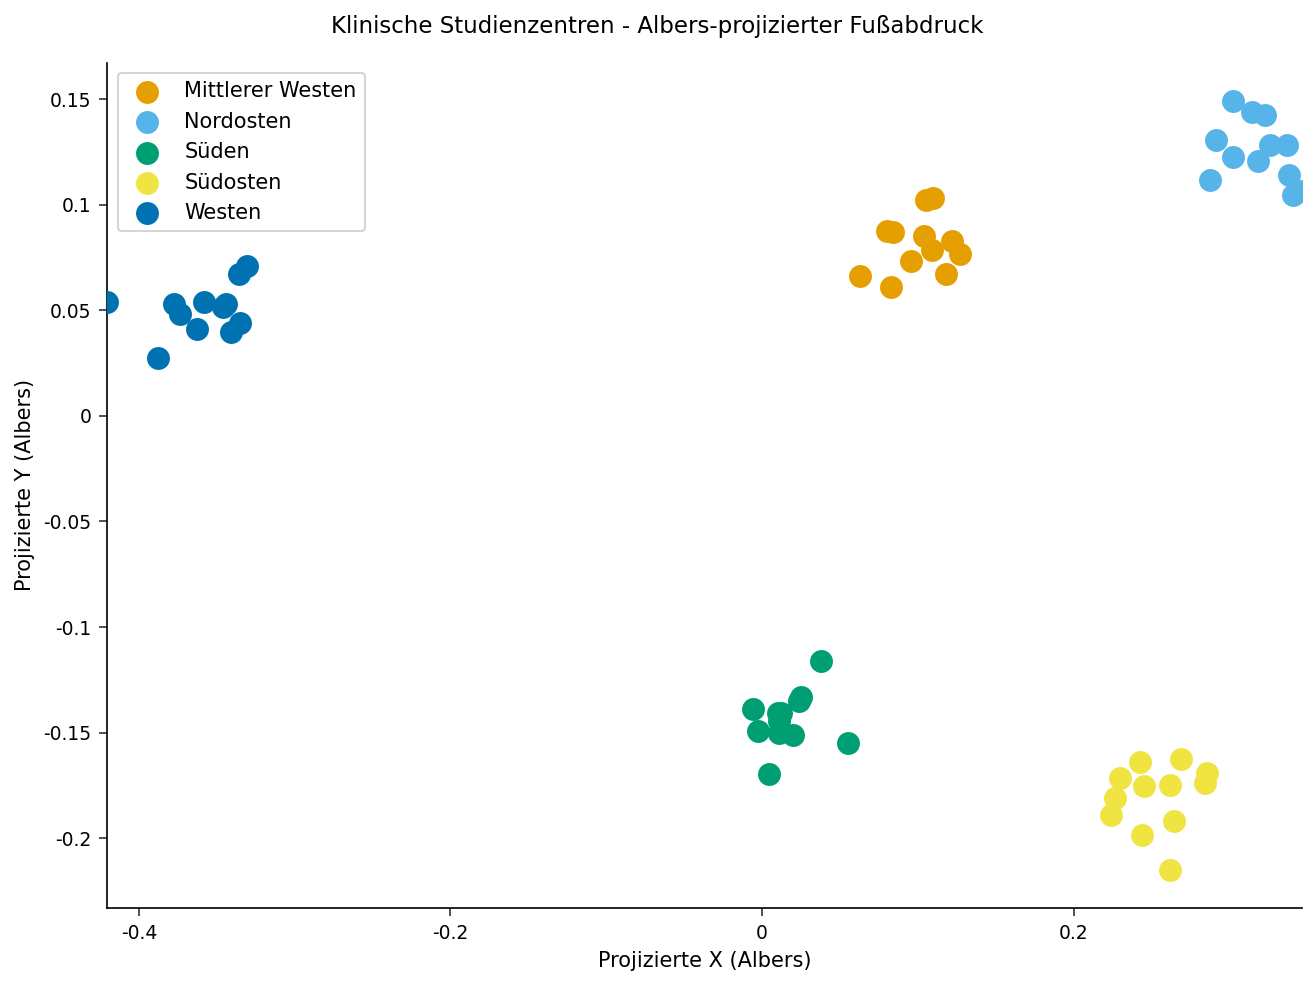

In [5]:
PROZEDUR SGPLOT DATEN=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS BEZEICHNUNG="Projizierte X (Albers)";
    YAXIS BEZEICHNUNG="Projizierte Y (Albers)";
    TITEL "Klinische Studienzentren - Albers-projizierter Fußabdruck";
AUSFÜHREN;

## Ergebnisse interpretieren

- **Albers (Schritt 2)** wandelte alle 60 Zentren in planare Koordinaten um und erhielt dabei die relative Fläche — die Cluster Westen, Mittlerer Westen, Nordosten, Süden und Südosten behalten ihren proportionalen räumlichen Fußabdruck, die richtige Grundlage für eine flächentreue Rekrutierungs-Heatmap.
- **Lambert mit Clipping (Schritt 3)** erhielt die lokale Form und verwarf durch das `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`-Fenster die synthetischen Zentren, die außerhalb des zusammenhängenden U.S.-Gebiets lagen — hier sank die Anzahl von 60 auf 58, sodass die beiden Koordinaten außerhalb des Rasters, die die Karte sonst gestreckt hätten, vor der Projektion entfernt wurden.
- **Gnomonisch mit `ASIS` (Schritt 4)** zentrierte die Projektion auf das Landesinnere und erzeugte dank `ASIS` einen Datensatz, der sowohl die projizierten `X`/`Y`- als auch die ursprünglichen `LONG`/`LAT`-Werte trägt. Großkreise erscheinen als gerade Linien, sodass Luftlinien-Entfernungen auf dieser Karte die tatsächlich kürzesten Wege zwischen Zentren annähern.
- **Der dargestellte Fußabdruck (Schritt 5)** bestätigt, dass die Projektion funktioniert hat: Das Auftragen der Albers-`X`/`Y`-Werte nach Region platziert die fünf Hub-Cluster in den erwarteten Ecken der Ebene — den flächentreuen Zentrenfußabdruck, den die Zusammenfassung versprochen hat.

**Erkenntnis für Clinical Operations:** Die Projektion ist nicht kosmetisch. Wählen Sie **Albers** für flächentreue Rekrutierungsdichte, **Lambert** für formtreue Überlagerungen mit regionalem Clipping und **Gnomonisch**, wenn die Reisedistanz zwischen Zentren die Analyse bestimmt. Wie Schritt 5 zeigt, lässt sich der projizierte `OUT=`-Datensatz direkt in PROC SGPLOT (oder PROC GMAP) einspeisen, um die finale Zentrenkarte darzustellen.